# Analisis Dataset SDSC-HTTP (Granularitas Detik)
Notebook ini memproses log akses ASCII **SDSC-HTTP** (24 jam), mem-parsing data waktu dengan format kustom, mengelompokkan request ke virtual microservices, dan melakukan agregasi ke **Requests Per Second (RPS)** tingkat detik.

Dataset ini merepresentasikan beban kerja web server San Diego Supercomputer Center (SDSC) pada Agustus 1995.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/sdsc-http.txt'

print("Membaca dan mem-parsing log file SDSC-HTTP secara efisien...")
start_time = time.time()
data = []

with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.strip().split(':', 1)
            host = parts[0]
            rest = parts[1].strip()
            
            # Ambil timestamp 24 karakter pertama
            ts_str = rest[:24]
            dt = datetime.strptime(ts_str, '%a %b %d %H:%M:%S %Y')
            
            file_part = rest[rest.find('(')+1 : rest.find(')')]
            
            op_part = rest[rest.find(')')+2 :].strip()
            if op_part.startswith('Layout') or op_part.startswith(':'):
                op_part = op_part.lstrip(':').strip()
                
            method = 'GET'
            if 'POST' in op_part:
                method = 'POST'
            elif 'HEAD' in op_part:
                method = 'HEAD'
                
            ext = file_part.split('.')[-1].split('?')[0].lower() if '.' in file_part else 'no_ext'
            
            data.append((dt, host, method, ext, file_part))
        except Exception:
            continue

df = pd.DataFrame(data, columns=['datetime', 'host', 'method', 'extension', 'filename'])
df['host'] = df['host'].astype('category')
df['method'] = df['method'].astype('category')
df['extension'] = df['extension'].astype('category')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file SDSC-HTTP secara efisien...


Total baris log: 28338 (diproses dalam 0.62 detik)


,host,method,extension,filename
datetime,,,,
1995-08-22 00:00:00,1+1,GET,gif,/SDSC/Partners/vrml/Images/cube.gif
1995-08-22 00:00:00,1+1,GET,gif,/SDSC/Partners/vrml/Images/cone.gif
1995-08-22 00:00:05,2+1,GET,gif,/wow/mexico/resort/redb.gif
1995-08-22 00:00:09,3+1,GET,html,/wow/mexico/cancun/cancan.html
1995-08-22 00:00:16,1+1,GET,html,/SDSC/Partners/vrml/software/browsers.html


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 28338 entries, 1995-08-22 00:00:00 to 1995-08-22 23:59:41
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   host       28338 non-null  category
 1   method     28338 non-null  category
 2   extension  28338 non-null  category
 3   filename   28338 non-null  str     
dtypes: category(3), str(1)
memory usage: 581.4 KB


In [4]:
# Pemetaan ke virtual microservices berdasarkan ekstensi file dan method
# Content_Service -> html, htm, txt, no_ext
# Media_Service -> gif, jpg, jpeg, xbm
# DynamicAPI_Service -> cgi extension atau POST method

html_exts = {'html', 'htm', 'txt', 'no_ext'}
image_exts = {'gif', 'jpg', 'jpeg', 'xbm'}
api_exts = {'cgi', 'pl'}

df['service'] = 'Others'
df.loc[df['extension'].isin(html_exts), 'service'] = 'Content_Service'
df.loc[df['extension'].isin(image_exts), 'service'] = 'Media_Service'
df.loc[(df['extension'].isin(api_exts)) | (df['method'] == 'POST'), 'service'] = 'DynamicAPI_Service'

df['service'] = df['service'].astype('category')
print(df['service'].value_counts())


service
Media_Service         14510
Content_Service       12792
DynamicAPI_Service      945
Others                   91
Name: count, dtype: int64


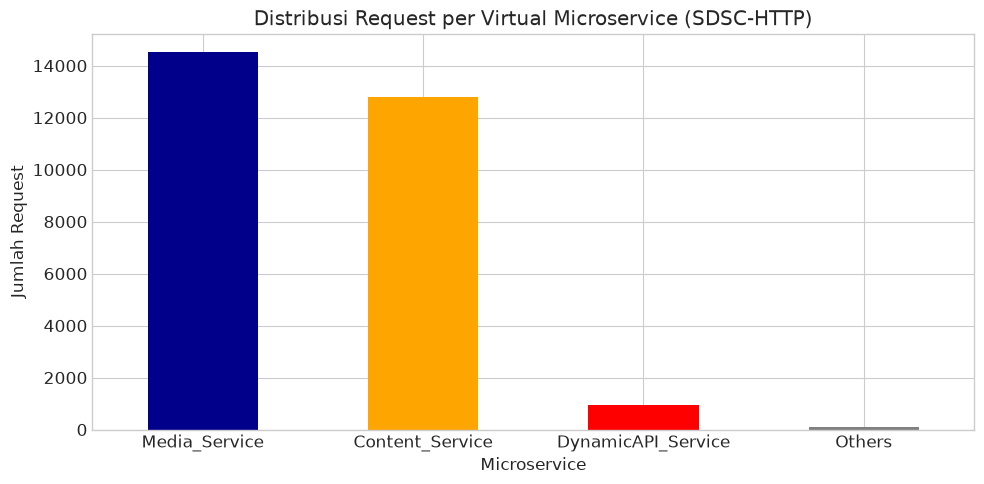

In [5]:
service_counts = df['service'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color=['darkblue', 'orange', 'red', 'grey'])
plt.title('Distribusi Request per Virtual Microservice (SDSC-HTTP)')
plt.xlabel('Microservice')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resample ke 1 detik untuk menghitung total RPS (Spans 24 hours)
print("Menghitung total RPS per detik...")
start_str = "1995-08-22 00:00:00"
end_str = "1995-08-22 23:59:41"
idx_full = pd.date_range(start=start_str, end=end_str, freq='s')

total_rps = df.resample('1s').size().reindex(idx_full, fill_value=0)

# Hitung RPS untuk masing-masing virtual microservice
print("Menghitung RPS per-layanan...")
services = df['service'].cat.categories
rps_services = {}

for svc in services:
    svc_df = df[df['service'] == svc]
    rps_services[svc] = svc_df.resample('1s').size().reindex(idx_full, fill_value=0)

# Gabungkan ke satu DataFrame
rps_df = pd.DataFrame(rps_services)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...
Menghitung RPS per-layanan...


,Content_Service,DynamicAPI_Service,Media_Service,Others,total_rps
1995-08-22 00:00:00,0,0,2,0,2
1995-08-22 00:00:01,0,0,0,0,0
1995-08-22 00:00:02,0,0,0,0,0
1995-08-22 00:00:03,0,0,0,0,0
1995-08-22 00:00:04,0,0,0,0,0


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik:")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik:
      Content_Service  DynamicAPI_Service  Media_Service    Others  total_rps
min          0.000000             0.00000       0.000000  0.000000   0.000000
mean         0.148086             0.01094       0.167975  0.001053   0.328054
max          7.000000             3.00000      11.000000  1.000000  11.000000


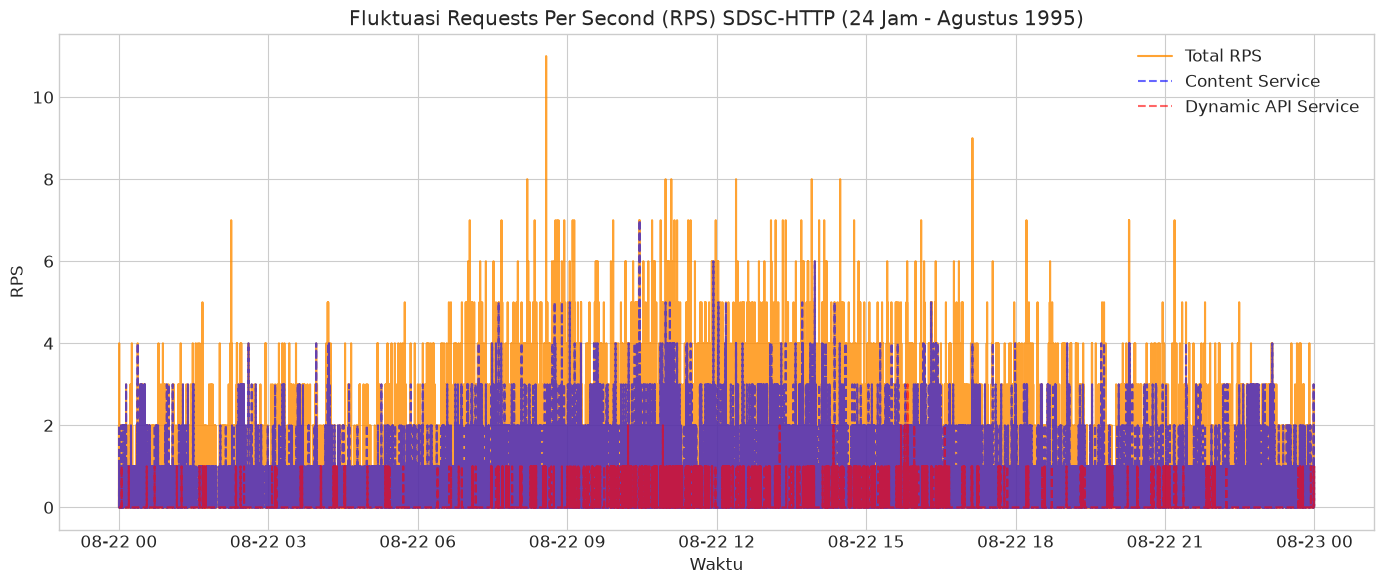

In [8]:
# Plot runtun waktu total RPS
plt.figure(figsize=(14, 6))
plt.plot(rps_df.index, rps_df['total_rps'], label='Total RPS', color='darkorange', alpha=0.8)
plt.plot(rps_df.index, rps_df['Content_Service'], label='Content Service', color='blue', alpha=0.6, linestyle='--')
plt.plot(rps_df.index, rps_df['DynamicAPI_Service'], label='Dynamic API Service', color='red', alpha=0.6, linestyle='--')

plt.title('Fluktuasi Requests Per Second (RPS) SDSC-HTTP (24 Jam - Agustus 1995)')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


Trafik puncak terjadi pada: 1995-08-22 08:34:37 dengan 11 RPS


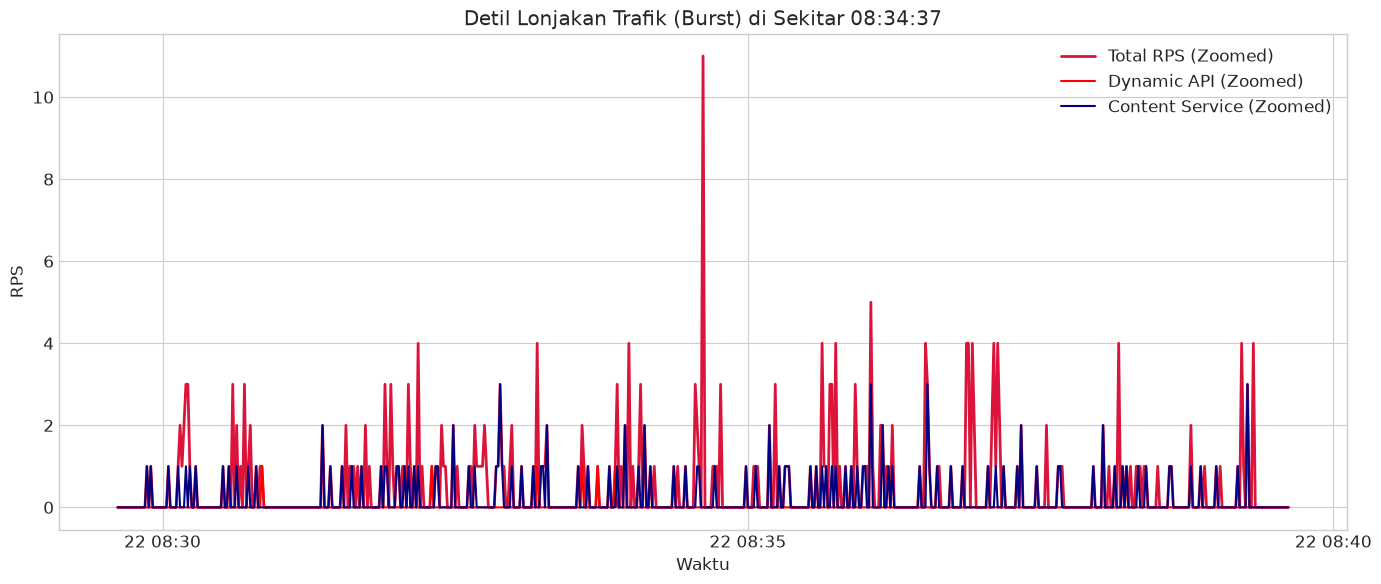

In [9]:
# Cari timestamp di mana terjadi lonjakan (peak)
peak_time = rps_df['total_rps'].idxmax()
print(f"Trafik puncak terjadi pada: {peak_time} dengan {rps_df['total_rps'].max()} RPS")

# Zoom ke area sekitar peak (+/- 5 menit)
zoom_start = peak_time - pd.Timedelta(minutes=5)
zoom_end = peak_time + pd.Timedelta(minutes=5)
zoomed_df = rps_df.loc[zoom_start:zoom_end]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (Zoomed)', color='crimson', linewidth=2)
plt.plot(zoomed_df.index, zoomed_df['DynamicAPI_Service'], label='Dynamic API (Zoomed)', color='red')
plt.plot(zoomed_df.index, zoomed_df['Content_Service'], label='Content Service (Zoomed)', color='navy')

plt.title(f'Detil Lonjakan Trafik (Burst) di Sekitar {peak_time:%H:%M:%S}')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV
output_csv_path = 'dataset/aggregated_sdsc_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_sdsc_rps.csv


## Kesimpulan Skenario Autoscaling
Dataset **SDSC-HTTP** merepresentasikan beban kerja pusat superkomputer pada pertengahan 90-an yang stabil namun memiliki lonjakan harian reguler yang khas.